# Bootstrap examples

`bootstrap` function can be used to bootstrap the zero coupon yields from coupon bonds available in the markets

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from quantpy.instruments.CouponBond import CouponBond
from quantpy.instruments.CouponBond import bootstrap
from quantpy import QuantDatetime

plt.style.use('seaborn-v0_8')
example_root = Path(os.path.abspath(""))

This bootstrap example uses the prices for bonds issued by the Republic of Finland. The prices of the bonds were sourced from Refinitiv. The included bonds are bonds with euro denomination

In [2]:
bond_date  = "2026-03-06"
price_date = "2026-02-27"

In [3]:
bond_df  = pd.read_csv(example_root / "data" / f"fi_bonds_{bond_date}.csv")
price_df = pd.read_csv(example_root / "data" / f"fi_history_{bond_date}.csv")

df = bond_df.merge(price_df.query(f"Date == '{price_date}'"), how="left", left_on="RIC", right_on="RIC")
df.head()

,RIC,ISIN,Issuer,Ticker,CouponRate,MaturityDate,IssueDate,Currency,FaceIssuedUSD,NextPayDate,...,Date,Bid,Ask,Accrual,MidYield,Convexity,ModDuration,DollarDuration,Z_Spread,OIS_Spread
0,FI0197959=,FI4000197959,"Finland, Republic of (Government)",FINL,0.5,2026-04-15,2016-03-08,Euro,8219911123,NaN,...,2026-02-27,99.760,99.900,0.4411,1.9378,0.0276,0.1175,0.1180,56.1388,0.5566
1,FI0590971=,FI4000590971,"Finland, Republic of (Government)",FIBL,0.0,2026-05-13,2025-06-05,Euro,8488634512,NaN,...,2026-02-27,99.607,99.615,0.0000,1.9959,0.2270,0.1934,0.1930,1.6188,6.4538
2,FI0592183=,FI4000592183,"Finland, Republic of (Government)",FIBL,0.0,2026-08-13,2025-09-11,Euro,6070124008,NaN,...,2026-02-27,99.095,99.110,0.0000,2.0111,0.6321,0.4439,0.4400,-10.1619,8.5758
3,FI0511449=,FI4000511449,"Finland, Republic of (Government)",FINL,0.0,2026-09-15,2021-08-31,Euro,4647402340,NaN,...,2026-02-27,98.898,98.944,0.0000,2.0313,0.5643,0.5312,0.5255,-8.4691,11.1742
4,FI0598396=,FI4000598396,"Finland, Republic of (Government)",FIBL,0.0,2026-11-13,2026-01-09,Euro,2710499988,NaN,...,2026-02-27,98.570,98.638,0.0000,2.0045,1.1630,0.6944,0.6850,-6.0684,9.1502


In [4]:
current_date = QuantDatetime(*tuple(map(int, price_date.split('-'))), calendar="London", convention="ACT/360")
bonds  = []
prices = []

for _, row in df.iterrows():
  issuance_date = QuantDatetime(*tuple(map(int, row["IssueDate"].split('-'))), calendar="London", convention="ACT/360")
  maturity_date = QuantDatetime(*tuple(map(int, row["MaturityDate"].split('-'))), calendar="London", convention="ACT/360")
  coupon_rate   = float(row["CouponRate"]) / 100.
  coupon_freq   = 1
  notional      = 100
  mid_price     = (float(row["Bid"]) + float(row["Ask"])) / 2. + float(row["Accrual"])
  
  bonds.append(CouponBond(issuance_date, maturity_date, coupon_rate, notional, coupon_freq))
  prices.append(mid_price)
  
print(repr(bonds[0]))

Maturity date: 2026-04-15 16:00:00.000
Notional: 100
Coupon rate: 0.005
Coupon frequency: 1
Issuance date: 2016-03-08 16:00:00.000
Zero pricer: Discount


In [5]:
print(bonds[0].zeros)

[Maturity date: 2026-04-15 16:00:00.000
Notional: 100.49999999999999
Pricer: Discount, Maturity date: 2025-04-15 16:00:00.000
Notional: 0.5
Pricer: Discount, Maturity date: 2024-04-15 16:00:00.000
Notional: 0.5
Pricer: Discount, Maturity date: 2023-04-15 16:00:00.000
Notional: 0.5
Pricer: Discount, Maturity date: 2022-04-15 16:00:00.000
Notional: 0.5
Pricer: Discount, Maturity date: 2021-04-15 16:00:00.000
Notional: 0.5
Pricer: Discount, Maturity date: 2020-04-15 16:00:00.000
Notional: 0.5
Pricer: Discount, Maturity date: 2019-04-15 16:00:00.000
Notional: 0.5
Pricer: Discount, Maturity date: 2018-04-15 16:00:00.000
Notional: 0.5
Pricer: Discount, Maturity date: 2017-04-15 16:00:00.000
Notional: 0.5
Pricer: Discount]


Note that commonly applied day-count convention with coupon bearing bonds is `ACT/360`

Having defined the bonds and their prices the `bootstrap` function can be used

In [6]:
tup_arr = bootstrap(current_date, bonds, prices)

The found discount factors are

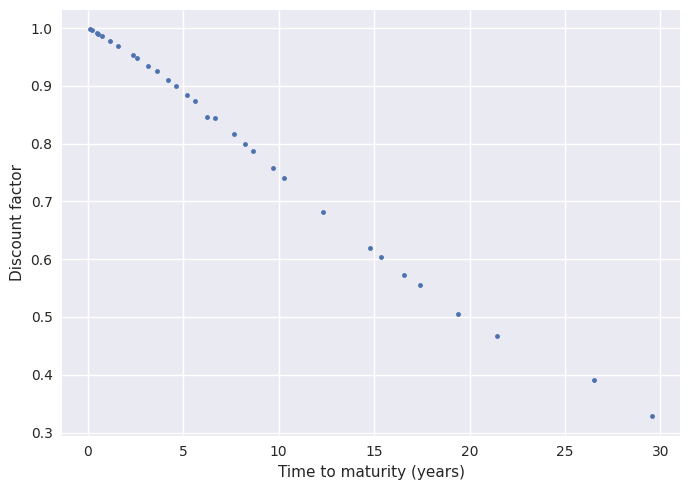

In [7]:
time_to_maturity = np.array([tup[0] for tup in tup_arr])
discount_factors = np.array([tup[1] for tup in tup_arr])

fig = plt.figure(figsize=(7, 5))

plt.plot(time_to_maturity, discount_factors, '.')
plt.ylabel("Discount factor")
plt.xlabel("Time to maturity (years)")

fig.tight_layout()

plt.show()

Corresponding yields are

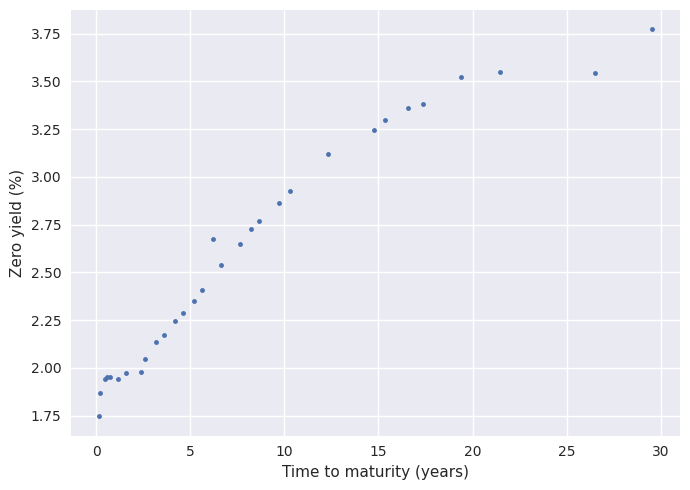

In [8]:
zero_yields = -np.log(discount_factors) / time_to_maturity

fig = plt.figure(figsize=(7, 5))

plt.plot(time_to_maturity, zero_yields * 100, '.')
plt.ylabel("Zero yield (%)")
plt.xlabel("Time to maturity (years)")

fig.tight_layout()

plt.show()

In [9]:
yield_df = pd.DataFrame(columns=["TimeToMaturity", "ZeroYield"])
yield_df["TimeToMaturity"] = time_to_maturity
yield_df["ZeroYield"]      = zero_yields

yield_df.to_csv(example_root / "data" / f"fi_yields_{price_date}.csv", index=False)

## Latex tables

Write the found tables into a Latex like format that can be copied to documentation

In [10]:
include_columns = ["ISIN", "CouponRate", "MaturityDate", "IssueDate", "Bid", "Ask", "Accrual"]

print(r"\hline")
print(" & ".join([str(val) for val in include_columns]) + r" \\")
print(r"\hline")
print(r"\hline")

for i, row in df.iterrows():
  vals = row[include_columns].to_list()
  print(" & ".join([str(val) for val in vals]) + r" \\")
  print(r"\hline")

\hline
ISIN & CouponRate & MaturityDate & IssueDate & Bid & Ask & Accrual \\
\hline
\hline
FI4000197959 & 0.5 & 2026-04-15 & 2016-03-08 & 99.76 & 99.9 & 0.4411 \\
\hline
FI4000590971 & 0.0 & 2026-05-13 & 2025-06-05 & 99.607 & 99.615 & 0.0 \\
\hline
FI4000592183 & 0.0 & 2026-08-13 & 2025-09-11 & 99.095 & 99.11 & 0.0 \\
\hline
FI4000511449 & 0.0 & 2026-09-15 & 2021-08-31 & 98.898 & 98.944 & 0.0 \\
\hline
FI4000598396 & 0.0 & 2026-11-13 & 2026-01-09 & 98.57 & 98.638 & 0.0 \\
\hline
FI4000527551 & 1.375 & 2027-04-15 & 2022-08-30 & 99.244 & 99.364 & 1.213 \\
\hline
FI4000278551 & 0.5 & 2027-09-15 & 2017-09-06 & 97.636 & 97.756 & 0.2315 \\
\hline
FI4000037635 & 2.75 & 2028-07-04 & 2012-02-07 & 101.542 & 101.662 & 1.8233 \\
\hline
FI4000348727 & 0.5 & 2028-09-15 & 2018-09-04 & 96.003 & 96.123 & 0.2315 \\
\hline
FI4000557525 & 2.875 & 2029-04-15 & 2023-08-30 & 101.989 & 102.109 & 2.5363 \\
\hline
FI4000369467 & 0.5 & 2029-09-15 & 2019-02-12 & 94.108 & 94.228 & 0.2315 \\
\hline
FI4000577952 & 2

In [11]:
include_columns = yield_df.columns
yield_df["ZeroYield"] = yield_df["ZeroYield"] * 100

print(r"\hline")
print(" & ".join([str(val) for val in include_columns]) + r" \\")
print(r"\hline")
print(r"\hline")

for i, row in yield_df.iterrows():
  vals = row[include_columns].to_list()
  print(" & ".join([f"{val:.3f}" for val in vals]) + r" \\")
  print(r"\hline")

\hline
TimeToMaturity & ZeroYield \\
\hline
\hline
0.131 & 1.747 \\
\hline
0.208 & 1.871 \\
\hline
0.464 & 1.943 \\
\hline
0.556 & 1.953 \\
\hline
0.719 & 1.954 \\
\hline
1.144 & 1.943 \\
\hline
1.569 & 1.975 \\
\hline
2.383 & 1.980 \\
\hline
2.586 & 2.048 \\
\hline
3.175 & 2.136 \\
\hline
3.600 & 2.171 \\
\hline
4.189 & 2.244 \\
\hline
4.614 & 2.289 \\
\hline
5.203 & 2.349 \\
\hline
5.628 & 2.408 \\
\hline
6.219 & 2.674 \\
\hline
6.644 & 2.536 \\
\hline
7.658 & 2.650 \\
\hline
8.247 & 2.726 \\
\hline
8.672 & 2.768 \\
\hline
9.686 & 2.863 \\
\hline
10.278 & 2.925 \\
\hline
12.306 & 3.119 \\
\hline
14.761 & 3.244 \\
\hline
15.350 & 3.295 \\
\hline
16.586 & 3.361 \\
\hline
17.378 & 3.383 \\
\hline
19.408 & 3.526 \\
\hline
21.436 & 3.548 \\
\hline
26.511 & 3.542 \\
\hline
29.553 & 3.773 \\
\hline
